In [8]:
from langgraph.graph import StateGraph ,START,END
from typing import TypedDict



In [3]:
class BatsmanState(TypedDict):
    runs:int
    balls:int
    fours:int
    sixes:int

    sr:float
    bpb:float
    boundary_percent:float
    summary:str

In [4]:
def cal_sr(state: BatsmanState):
    sr=(state['runs']/state['balls'])*100

    return {'sr':sr}

In [5]:
def cal_bpb(state: BatsmanState):
    bpb=(state['balls']/(state['fours']+state['sixes']));

    return {'bpb':bpb}

In [6]:
def cal_boundary_per(state:BatsmanState):
    bp=((state['fours']*4+state['sixes']*6)/state['runs'])*100

    return {'boundary_percent':bp}

In [7]:
def summary(state:BatsmanState):
    summary=f"""
    runs :{state['runs']}
    sr: {state['sr']}
    boundary per ball:{state['bpb']}
    """

    return {'summary':summary}

In [10]:
## define the graph , nodes and edges

graph=StateGraph(BatsmanState)

## create nodes
graph.add_node('cal_sr',cal_sr)
graph.add_node('cal_bpb',cal_bpb)
graph.add_node('cal_boundary_per',cal_boundary_per)
graph.add_node('summary',summary)



## connects node through edges
graph.add_edge(START,'cal_sr')
graph.add_edge(START,'cal_bpb')
graph.add_edge(START,'cal_boundary_per')

graph.add_edge('cal_sr','summary')
graph.add_edge('cal_bpb','summary')
graph.add_edge('cal_boundary_per','summary')
graph.add_edge('summary',END)

workflow=graph.compile()



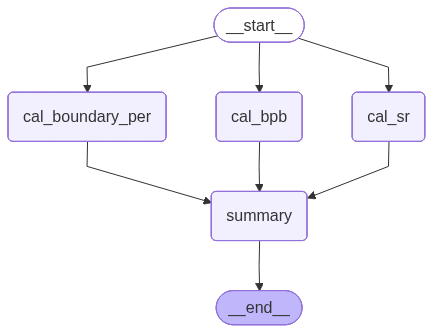

In [11]:
workflow

In [13]:
intial={
    'runs':98,
    'balls':33,
    'fours':6,
    'sixes':8
}

result=workflow.invoke(intial)
print(result['summary'])


    runs :98
    sr: 296.969696969697
    boundary per ball:2.357142857142857
    
